# SFINCS Scenario Stats

In [1]:
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

# model, scenario, storage, and catalog paths.
from sfincs_runs.config import load_sfincs_runtime as load_runtime
# event selection, SFINCS staging, and handoff readiness.
from sfincs_runs.scenarios import scenario_stats as stats
from sfincs_runs.scenarios import build_flood_event_outcome_catalogue
# flood, forcing, and post-run plots.
from sfincs_runs import diagnostics as sfincs_diagnostics

runtime = load_runtime(location_root, wave=True, create_base_model_dir=False)
config = runtime.config
paths = runtime.paths
pd.set_option("display.max_columns", 80)

## Rerun Control


In [ ]:
rerun = True

# Read parallelism for the map-scanning cells (Step 2b health, Step 5 stats, Step 8 catalogue).
# These are I/O-bound over hundreds of SFINCS maps per scenario; reading in parallel cuts the
# all-scenarios passes from ~tens of minutes to a few. None -> auto (min(cpu_count, 16));
# set to 1 to force the serial path for debugging.
N_WORKERS = None


## Step 0: Load Stats Inputs

Stats are not raw SFINCS outputs alone. They need three folder families:

- `scenarios_root`: prepared SFINCS event folders with `sfincs.inp`, `sfincs.bzs`, and manifests.
- `storage_root`: persisted solver outputs, especially `sfincs_map.nc`.
- `design_outputs_root`: `design_events` outputs that explain the sampled peak, template, return period, and SLR scenario.

These paths come from `sfincs_runs/project.yaml` through `build_paths`.

In [3]:
settings = pd.Series(
    {
        "scenarios_root": str(paths["scenarios_root"]),
        "storage_root": str(paths["storage_root"]),
        "stats_root": str(paths["stats_root"]),
        "design_outputs_root": str(paths["design_outputs_root"]),
        "land_threshold_m": 0.0,
        "huthresh_m": 0.01,
        "impact_threshold_m": 0.10,
    },
    name="value",
)
settings


scenarios_root         /home/grahamhults/projects/Flood-RM/locations/...
storage_root           /home/grahamhults/projects/Flood-RM/locations/...
stats_root             /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root    /home/grahamhults/projects/Flood-RM/locations/...
land_threshold_m                                                     0.0
huthresh_m                                                          0.01
impact_threshold_m                                                   0.1
Name: value, dtype: object

## Step 1

- Which SLR scenario generated this run?
- What return period was sampled?
- Which historical hydrograph template shaped the event?
- Does the SFINCS boundary file match the expected design-event peak?

In [4]:
# Evaluate every scenario declared in config (base + each SLR projection).
scenario_cfg = config.get("scenarios") or {"base": {}}
scenarios = list(scenario_cfg)
scenario_path_by = {s: sfincs_diagnostics.scenario_paths(paths, s) for s in scenarios}

scenario_summaries, scenario_rows_by, design_rows_by, design_attrs_by = {}, {}, {}, {}
for s in scenarios:
    summ, rows = stats.load_scenario_build(scenario_path_by[s]["scenarios_root"])
    scenario_summaries[s], scenario_rows_by[s] = summ, rows
    design_rows_by[s], design_attrs_by[s] = stats.load_design_events(summ)

# Base is the reference for the single-event deep-dive (Step 3/4) and benchmark selection (Step 11).
scenario_summary, scenario_rows = scenario_summaries["base"], scenario_rows_by["base"]
design_rows, design_attrs = design_rows_by["base"], design_attrs_by["base"]

display(pd.DataFrame({
    s: {
        "design_scenario": scenario_summaries[s].get("design_scenario"),
        "slr_offset_m": float((scenario_cfg.get(s) or {}).get("slr_offset_m", 0.0)),
        "event_count": scenario_summaries[s].get("event_count"),
    }
    for s in scenarios
}).T)

design_frame = pd.DataFrame.from_dict(design_rows, orient="index")
cols = [c for c in ["sample_rp_years", "peak_m", "absolute_peak_m", "template_id", "template_peak_time", "tail_morph_factor"] if c in design_frame]
design_frame[cols].head()


,design_scenario,slr_offset_m,event_count
base,base,0.0,514
noaa_int_2050,noaa_int_2050,0.3,514
noaa_int_2100,noaa_int_2100,1.1,514


""


## Step 2: Pick Completed Events

A scenario folder is the preferred prepared input. A completed run also has `sfincs_map.nc` in the storage folder.

If `data/sfincs/scenarios` only contains a debug or partial staging set, but `data/sfincs/run_outputs` contains self-contained completed run folders, the next cell falls back to those run-output folders so the evaluation catalogue does not silently shrink.

In [5]:
# Completed events per scenario (scenario folders are the normal unit; run-output folders
# are a safe fallback when they carry sfincs.inp/bzs + manifest + map output).
completed_by = {}
for s in scenarios:
    sp = scenario_path_by[s]
    inv = stats.completed_event_inventory(sp["scenarios_root"], sp["storage_root"])
    completed_by[s] = inv["completed_events"]

# Base events drive the single-event deep-dive (Step 3/4).
completed_events = completed_by["base"]
LIMIT = None  # set to an int to subset the single-event/preview steps
selected_events = completed_events[:LIMIT] if LIMIT is not None else completed_events

display(pd.Series({s: len(completed_by[s]) for s in scenarios}, name="completed_events_by_scenario"))
print("base selected events:", len(selected_events), "| first:", selected_events[0].name if selected_events else None)


base             514
noaa_int_2050    514
noaa_int_2100    514
Name: completed_events_by_scenario, dtype: int64

base selected events: 514 | first: design_0001


## Step 2b: Health Check All Runs

Before trusting any aggregate, confirm each event finished cleanly. This cell walks every event in `completed_events` and flags anomalies on three axes:

- `returncode` from `run_metadata.json` (should be 0).
- `sfincs_map.nc` file size (a normal run is tens of MB; near zero means the solver wrote no map output).
- finite-value fraction of the final-timestep `zs` slice (near zero means the solver wrote NaNs across the active grid).

Also surfaces per-event wall-clock duration so outliers — events much slower than the rest — are visible before any downstream analysis. The slow step is opening 500 NetCDFs once (~1 min on a warm cache).

In [ ]:
# Evaluate across ALL scenario outputs: base + every SLR projection declared in config.
# scenario_roots is the single source of truth reused downstream (Step 8, Step 11).
scenario_roots = sfincs_diagnostics.slr_scenario_storage_roots(
    paths["storage_root"], list(config.get("scenarios", {"base": {}}))
)
runs = sfincs_diagnostics.completed_runs_by_scenario(scenario_roots)

# Per-run completion health across all scenarios, read in parallel (N_WORKERS).
health = sfincs_diagnostics.health_check_table(runs, workers=N_WORKERS)

flags = {
    "bad returncode":        health["returncode"].fillna(-1) != 0,
    "tiny map (<1 MB)":      health["map_mb"] < 1.0,
    "open failed":           health["open_error"] != "",
    "empty zs (<5% finite)": health["zs_finite_frac"] < 0.05,
    "missing timesteps":     health["n_timesteps"] < 2,
}

print(f"events checked: {len(health)} across {health['design_scenario'].nunique()} scenarios\n")
display(health.groupby("design_scenario").size().rename("events_checked").to_frame().T)
for label, mask in flags.items():
    print(f"  {label:24s} {int(mask.sum())}")

print("\nduration (min):")
display(health["duration_min"].describe().to_frame().T)

flagged_mask = pd.Series(False, index=health.index)
for mask in flags.values():
    flagged_mask = flagged_mask | mask

if flagged_mask.any():
    print(f"\n{int(flagged_mask.sum())} anomalous events:")
    display(health.loc[flagged_mask].sort_values(["design_scenario", "event_id"]))
else:
    print("\nAll events look clean.")


## Step 3: Inspect One Event End to End

For one event, compare the design-event forcing metadata with SFINCS results.

Important metric logic:
- `zs - zb` gives water depth.
- land cells are active cells with bed elevation above `land_threshold_m`.
- baseline wet land at `t0` is not counted as new impact.
- incremental flood depth measures added land depth above the `t0` baseline.
- impact extent uses the configured `impact_threshold_m`.

In [7]:
if not selected_events:
    raise RuntimeError("No completed SFINCS events found. Run scenarios first.")

event_dir = selected_events[0]
row = stats.event_stats(
    event_dir,
    paths["storage_root"],
    settings["land_threshold_m"],
    settings["huthresh_m"],
    settings["impact_threshold_m"],
    scenario_summary,
    scenario_rows,
    design_rows,
    design_attrs,
)

focus = [
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years", "template_id",
    "driver_h_magnitude", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
]
pd.Series({k: row.get(k) for k in focus}, name=event_dir.name)


event_id                                design_0001
design_scenario                                base
design_slr_offset_m                             0.0
sample_rp_years                            0.155722
template_id                                    None
driver_h_magnitude                             None
expected_bzs_peak_max_m                    1.523786
bzs_peak_max_m                                1.524
peak_incremental_land_depth_m              3.419192
peak_incremental_flooded_area_km2           15.1812
longest_incremental_flood_duration_h          143.0
area_incremental_flooded_ge_24h_km2          11.358
Name: design_0001, dtype: object

## Step 4: Visualize the One-Event Flood Signal

- left: max incremental land depth per cell.
- right: wet land cell count through time.

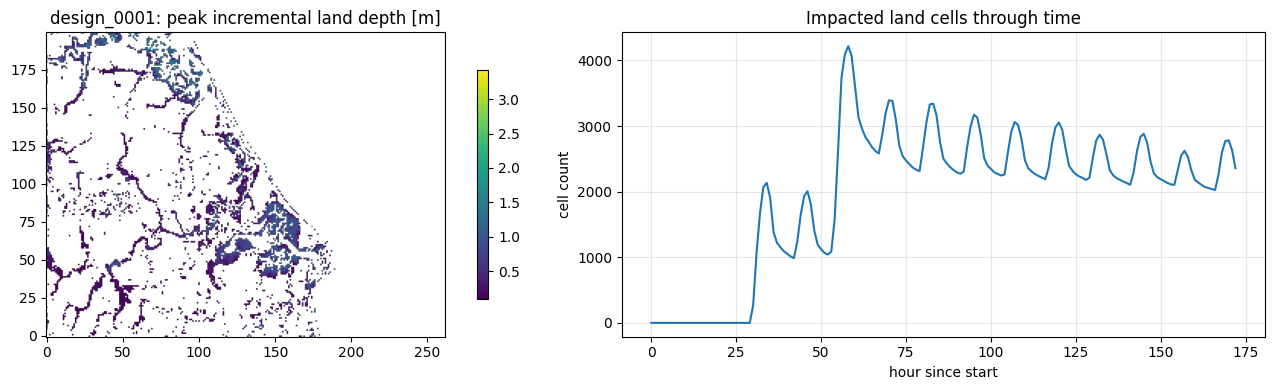

In [8]:
inp = stats.parse_sfincs_inp(event_dir / "sfincs.inp")
with xr.open_dataset(row["map_path"], decode_times=False) as ds:
    zs = np.asarray(ds["zs"].values, np.float32)
    zb = np.asarray(ds["zb"].values, np.float32)
    active = np.asarray(ds["msk"].values, float) > 0
    hours, dt = stats.parse_time(ds, inp)

depth = np.where(active[None,:,:], zs - zb[None,:,:], np.nan)
land = active & np.isfinite(zb) & (zb > settings["land_threshold_m"])
baseline = np.where(land, np.maximum(depth[0], 0.0), np.nan)
incremental = np.where(land[None,:,:], np.maximum(depth - np.nan_to_num(baseline, nan=0.0)[None,:,:], 0.0), np.nan)
impact = np.isfinite(incremental) & (incremental > settings["impact_threshold_m"])

peak_map = np.full(land.shape, np.nan, float)
impacted_cells = np.any(impact, axis=0)
if np.any(impacted_cells):
    peak_map[impacted_cells] = np.nanmax(np.where(impact, incremental, np.nan)[:, impacted_cells], axis=0)
impact_counts = impact.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(peak_map, origin="lower", cmap="viridis")
axes[0].set_title(f"{event_dir.name}: peak incremental land depth [m]")
fig.colorbar(im, ax=axes[0], shrink=0.75)

axes[1].plot(hours, impact_counts, lw=1.5)
axes[1].set_title("Impacted land cells through time")
axes[1].set_xlabel("hour since start")
axes[1].set_ylabel("cell count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5: Build the Stats Table

In [ ]:
# Per-event stats across ALL scenarios (design_scenario distinguishes base/2050/2100).
# Reads every scenario's maps in parallel (event_stats_table fans the heavy 3-D zs reads
# across N_WORKERS processes); cached to an all-scenarios CSV so reruns skip the recompute.
REBUILD_EVENT_STATS = True
all_stats_path = paths["stats_root"] / "notebook" / "scenario_stats_all_scenarios.csv"
all_stats_path.parent.mkdir(parents=True, exist_ok=True)

def _scenario_event_stats(s):
    sp = scenario_path_by[s]
    return stats.event_stats_table(
        completed_by[s], sp["storage_root"],
        land_threshold_m=settings["land_threshold_m"],
        huthresh_m=settings["huthresh_m"],
        impact_threshold_m=settings["impact_threshold_m"],
        scenario_summary=scenario_summaries[s], scenario_rows=scenario_rows_by[s],
        design_rows=design_rows_by[s], design_attrs=design_attrs_by[s],
        workers=N_WORKERS,
    )

df = None
if not REBUILD_EVENT_STATS and all_stats_path.exists():
    cached = pd.read_csv(all_stats_path)
    want = {(s, d.name) for s in scenarios for d in completed_by[s]}
    have = set(zip(cached.get("design_scenario", pd.Series(dtype=str)).astype(str),
                   cached.get("event_id", pd.Series(dtype=str)).astype(str)))
    if want.issubset(have):
        df = cached

if df is None:
    df = pd.concat([_scenario_event_stats(s) for s in scenarios], ignore_index=True)

df = df.sort_values(["design_scenario", "event_id"]).reset_index(drop=True)
df.to_csv(all_stats_path, index=False)
print("event stats ->", all_stats_path, "| rows:", len(df))

display(
    df.groupby("design_scenario")[["peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2"]]
    .agg(["median", "max"]).round(2)
)
df[[
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years",
    "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
]].head()


## Step 6: Check Alignment Between Inputs and Flood Outputs

- boundary peak from `sfincs.bzs` should track the design-event expected boundary peak.
- return period and SLR scenario should be available beside flood metrics.
- flood extent/depth rankings should point back to event IDs for map inspection.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = dict(zip(scenarios, plt.cm.viridis(np.linspace(0.1, 0.85, len(scenarios)))))
for s in scenarios:
    sub = df[df["design_scenario"] == s]
    axes[0].scatter(sub["expected_bzs_peak_max_m"], sub["bzs_peak_max_m"], s=16, alpha=0.6, color=colors[s], label=s)
    axes[1].scatter(sub["sample_rp_years"], sub["peak_incremental_land_depth_m"], s=16, alpha=0.6, color=colors[s], label=s)
    axes[2].scatter(sub["peak_incremental_land_depth_m"], sub["peak_incremental_flooded_area_km2"], s=16, alpha=0.6, color=colors[s], label=s)

axes[0].set_title("Expected vs written boundary peak")
axes[0].set_xlabel("expected bzs peak [m]"); axes[0].set_ylabel("written bzs peak [m]")
axes[1].set_xscale("log")
axes[1].set_title("Return period vs flood depth")
axes[1].set_xlabel("sample return period [years]"); axes[1].set_ylabel("peak incremental land depth [m]")
axes[2].set_title("Depth vs extent")
axes[2].set_xlabel("peak incremental land depth [m]"); axes[2].set_ylabel("peak incremental flood extent [km^2]")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(title="scenario", fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

df.sort_values("peak_incremental_land_depth_m", ascending=False)[[
    "event_id", "design_scenario", "sample_rp_years", "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2"
]].head(10)


## Step 7: Write Notebook Outputs

In [ ]:
outdir = paths["stats_root"] / "notebook"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "scenario_stats_notebook.csv"
df.to_csv(csv_path, index=False)

metric_cols = [
    "zsini_m", "baseline_t0_flooded_area_km2", "peak_incremental_land_depth_m",
    "peak_incremental_flooded_area_km2", "anytime_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "mean_incremental_flood_duration_h",
    "area_incremental_flooded_ge_24h_km2",
]
summary = {
    "event_count": int(len(df)),
    "design_outputs_root": scenario_summary.get("design_outputs_root"),
    "design_scenarios": sorted(str(x) for x in df["design_scenario"].dropna().unique()),
    "design_slr_offsets_m": sorted(float(x) for x in pd.to_numeric(df["design_slr_offset_m"], errors="coerce").dropna().unique()),
    "metric_summaries": {c: stats.series_summary(df, c) for c in metric_cols},
}

(outdir / "summary_notebook.json").write_text(__import__("json").dumps(summary, indent=2), encoding="utf-8")
pd.Series({"csv": str(csv_path), "summary": str(outdir / "summary_notebook.json")})


csv        /home/grahamhults/projects/Flood-RM/locations/...
summary    /home/grahamhults/projects/Flood-RM/locations/...
dtype: str

## Step 8: Export Run-Output Catalogue

In [ ]:
# Event-level evidence table per scenario: catalog drivers + run manifests + SFINCS outcomes.
# Each scenario writes to its own stats_root/notebook; the combined table carries design_scenario.
# Outcome metrics read maps in parallel (workers=N_WORKERS).
catalogue_path_by, catalogue_frames = {}, []
for s in scenarios:
    sp = scenario_path_by[s]
    outdir_s = Path(sp["stats_root"]) / "notebook"
    outdir_s.mkdir(parents=True, exist_ok=True)
    fc = build_flood_event_outcome_catalogue(
        completed_events=completed_by[s],
        paths=sp,
        settings=settings,
        health=health[health["design_scenario"] == s],
        outdir=outdir_s,
        rerun=rerun,
        scenario_summary=scenario_summaries[s],
        scenario_rows=scenario_rows_by[s],
        design_rows=design_rows_by[s],
        design_attrs=design_attrs_by[s],
        workers=N_WORKERS,
    )
    catalogue_path_by[s] = fc.catalogue_path
    catalogue_frames.append(pd.read_csv(fc.catalogue_path))

catalogue = pd.concat(catalogue_frames, ignore_index=True)
catalogue_path = catalogue_path_by["base"]  # base is the probability-catalogue reference (Step 11)
display(catalogue.groupby("design_scenario").size().rename("events").to_frame().T)
catalogue.groupby(["design_scenario", "severity_band"]).size().rename("events").reset_index()


## Step 9: Return-Period Flood Diagnostics

Read the exported event-outcome catalogue back as the analysis unit: one completed event per row, carrying the sampled joint return period, driver magnitudes, storm class, and SFINCS flood-response metrics.

In [ ]:
# Return-period flood diagnostics per scenario: severity vs depth/area/duration + storm-type panels.
responses = {}
for s in scenarios:
    responses[s] = sfincs_diagnostics.flood_response_diagnostics(catalogue_path_by[s])
    print(f"\n========== {s} ==========")
    display(responses[s].scope)
    display(responses[s].rp_band_stats.round(3))
    sfincs_diagnostics.plot_flood_response_diagnostics(responses[s])
    plt.show()

# Base reference for the benchmark selection in Step 11.
response = responses["base"]
flood = response.flood


## Step 10: Driver/flood-response diagnostic associations

This is a Maduwantha-style diagnostic review: storm-type colored driver/outcome panels and weighted standardized associations. It describes association between catalog drivers and SFINCS flood response; it is not counterfactual causal attribution.


In [ ]:
# Weighted driver/flood-response associations per scenario (Maduwantha-style, diagnostic only).
driver_assoc_path_by = {}
for s in scenarios:
    outdir_s = Path(scenario_path_by[s]["stats_root"]) / "notebook"
    driver_response = sfincs_diagnostics.driver_response_diagnostics(
        responses[s].flood,
        outdir=outdir_s,
        min_rows=8,
    )
    driver_assoc_path_by[s] = driver_response.associations_path
    print(f"\n========== {s} ==========")
    display(driver_response.top_associations)
    fig = sfincs_diagnostics.plot_driver_response_matrix(responses[s].flood, driver_response)
    if fig is not None:
        plt.show()

pd.Series({s: str(p) for s, p in driver_assoc_path_by.items()},
          name="driver_flood_response_associations_csv_by_scenario")


## Step 11: SLR Scenario Flood-Depth Comparison (Figure-10 style)

Compare a representative high-impact event near RP 10 / 100 / 500 across the SLR projections (`base`, `noaa_int_2050`, `noaa_int_2100`). Each projection re-ran the **same** Event Catalog under a fixed mean-sea-level offset (an MSL-Shift Scenario), so the per-event depth difference isolates the SLR effect. Top row: absolute flood depth per projection; bottom row: change vs `base`.

Adapts Maduwantha et al. (2026) Fig. 10 (flood-depth change with m.s.l. variability) to SLR *projection* scenarios. Each projection is evaluated on its own completed run set — depths are **not** pooled into one exceedance surface (SLR is a what-if boundary, not an added probability dimension). The benchmark event is the most consequential event near each return period (ranked by `peak_incremental_land_depth_m`), which in a tail-enriched catalog floods reliably; pass `rank_column="probability_weight"` for the most-likely event instead.


In [ ]:
# Reuse the all-scenario enumeration from the health check (single source of truth).
slr_offsets = {k: float((v or {}).get("slr_offset_m", 0.0)) for k, v in config.get("scenarios", {}).items()}
slr_roots = scenario_roots
slr_common = sfincs_diagnostics.common_completed_events(slr_roots)

# Representative most-consequential event near each benchmark return period, restricted to
# events completed in every scenario. response.flood (base outcomes) carries the catalog
# RP + flood-response metric used to rank; the same event_id is mapped under each SLR offset.
slr_benchmarks = sfincs_diagnostics.select_benchmark_events(
    response.flood,
    return_periods=(10, 100, 500),
    eligible_ids=slr_common,
)
display(pd.Series({
    "slr_scenarios": list(slr_roots),
    "slr_offsets_m": slr_offsets,
    "events_completed_all_scenarios": len(slr_common),
}, name="slr_comparison_scope"))
display(slr_benchmarks)

# One Figure-10-style panel set per benchmark return period:
# top row = absolute flood depth per SLR projection, bottom row = change vs base.
for _, b in slr_benchmarks.iterrows():
    comparison = sfincs_diagnostics.slr_event_depth_comparison(
        b["event_id"],
        slr_roots,
        offsets_m=slr_offsets,
        return_period_years=b["return_period_years"],
    )
    fig = sfincs_diagnostics.plot_slr_depth_comparison(comparison)
    fig.savefig(outdir / f"slr_depth_comparison_rp{int(b['return_period_years'])}.png", dpi=200, bbox_inches="tight")
    plt.show()
